In [1]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from scipy.stats import median_abs_deviation as MAD
import pathlib

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

## Define Helpers and Functions

In [2]:
def reject_outliers(X, m=3, scaling=False):
    """
    Adapted from https://medium.com/@saraswatp/exploring-data-anomalies-rejecting-outliers-with-python-660b1ed6bca6
    Returns a boolean mask where True = 'Keep' and False = 'Outlier'.
    """
    median = np.median(X, axis=0)
    # mad = MAD(X, axis=0, scale='normal')

    if scaling:
        mad = np.median(np.abs(X - median), axis=0) * 1.4826
    else:
        mad = np.median(np.abs(X - median), axis=0)
    
    upper_bound = median + m * mad
    lower_bound = median - m * mad

    mask = (X >= lower_bound) & (X <= upper_bound)

    return mask


def reject_outliers_by_subject_channel(burst_dict, value_key='peak_amp_base', m=3, scaling=False):
    """Compute outlier mask separately within each subject x chennel group.

    Args:
        burst_dict (dictionary): Burst dictionary containing at least:
            - 'subject'
            - 'channel'
            - value_key
        
        value_key (str, optional): Name of the feature on which to reject outliers. Defaults to 'peak_amp_base'.
        m (float, optional): Number of MADs from the median used as the cutoff. Defaults to 3.
        scaling (bool, optional): If True, scale MAD by 1.4826. Defaults to False.
    
    Returns:
        group_mask: ndarray of bool, shape (n_bursts,). Global mask with True = keep, False = outlier.
    """

    values = np.asarray(burst_dict[value_key])
    subjects_arr = np.asarray(burst_dict['subject'])
    channels_arr = np.asarray(burst_dict['channel'])

    n = len(values)
    if not (len(subjects_arr) == n and len(channels_arr) == n):
        raise ValueError(f"'subject', 'channel', and '{value_key}' must have the same length." )
    
    group_mask = np.ones(n, dtype=bool)
    unique_subjects = np.unique(subjects_arr)

    for sub in unique_subjects:
        sub_idx = subjects_arr == sub
        sub_channels = np.unique(channels_arr[sub_idx])

        for ch in sub_channels:
            idx = sub_idx & (channels_arr == ch)

            # Reject within this subject x channel subset
            local_mask = reject_outliers(values[idx], m=m, scaling=scaling)

            # Write local decisions back into full-length mask
            group_mask[idx] = local_mask

    return group_mask

In [3]:
def scaler_fit(X):
    median = np.median(X, axis=0)
    mad = MAD(X, axis=0, scale='normal')
    return median, mad


def scaler_transform(X, median, mad):
    return (X - median) / mad

In [4]:
def normalize_output_path(saved_file):
    raw_path = str(saved_file).replace('\r', '').replace('\n', '')
    path = pathlib.Path(raw_path)
    if path.exists():
        return path
    alt_path = pathlib.Path('outputs-5') / path.name
    if alt_path.exists():
        return alt_path
    alt_path = pathlib.Path('outputs-6') / path.name
    if alt_path.exists():
        return alt_path
    raise FileNotFoundError(f"Saved PCA output file not found: {saved_file}")

def get_saved_waveform_means(saved_file, n_bins, bin_number, pc_number, area):
    """Get mean waveforms for ON and OFF bursts within a specific PCA score bin,
    based on a saved PCA output file.
    """
    file = np.load(normalize_output_path(saved_file), allow_pickle=True).item()
    metadata = file['Metadata']
    cols = np.asarray(metadata['cols'], dtype=int)

    area_idx = np.asarray(stn_idx if area == 'stn' else c_idx, dtype=bool)

    n_bins = int(n_bins)
    bin_number = int(bin_number)
    pc_number = int(pc_number)

    score_list = file['fold-level']['score']  # Set of PCA score matrices for each value of n_bins    
    PCA_matrix = np.asarray(score_list[n_bins - 1])  # Select the score matrix corresponding to the specified n_bins
    
    n_bursts = area_idx.shape[0]  # Number of bursts in the selected area
    if PCA_matrix.shape[0] == n_bursts:  
        per_sample_scores = PCA_matrix
    elif PCA_matrix.shape[0] % n_bursts == 0:  # For each fold | 300,211 % 27,301 = 0 --> 11 folds
        n_folds = PCA_matrix.shape[0] // n_bursts
        per_sample_scores = PCA_matrix.reshape(n_folds, n_bursts, -1).mean(axis=0)
    
    pc_idx = cols[pc_number - 1]  # Map the 1-based pc_number to the correct column index in the score matrix
    PCA_scores = per_sample_scores[:, pc_idx]  # Extract the PCA scores for every burst

    bin_edges = np.percentile(PCA_scores[area_idx], np.linspace(0, 100, n_bins + 1))  # Compute bin edges based on percentiles of the PCA scores within the selected area's scores
    lower_bound = bin_edges[bin_number - 1]
    upper_bound = bin_edges[bin_number]

    if bin_number == n_bins:
        bin_mask = (PCA_scores >= lower_bound) & (PCA_scores <= upper_bound)
    else:
        bin_mask = (PCA_scores >= lower_bound) & (PCA_scores < upper_bound)

    selected_idx = area_idx & bin_mask
   
    on_mask = selected_idx & (correct_bursts['med'] == 'ON')
    off_mask = selected_idx & (correct_bursts['med'] == 'OFF')

    on_mean = np.mean(correct_bursts['waveform'][on_mask, :], axis=0)
    off_mean = np.mean(correct_bursts['waveform'][off_mask, :], axis=0)

    return on_mean, off_mean

## Data loading

### Channel labels

In [5]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

### Subject labels

In [6]:
data_dir = '../../data/preprocessed_data/'
out_path = '../../data/derivatives/'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


### Aggregating burst features of the STN and of motor cortex (C3,C4) across all subjects

In [7]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


## Perform light pre-processing
* Redefine the trial indices ensuring they're not overlapping between ON and OFF medication - subject-level based
* Convert burst time to ms
* Reject outliers based on their peak amplitude

In [8]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

In [9]:
burst_times = all_bursts['waveform_times'] * 1000 

In [10]:
outlier_mask = reject_outliers_by_subject_channel(
    all_bursts,
    value_key='peak_amp_base',
    m=3,
    scaling=False
    )

len_mask = len(outlier_mask)

correct_bursts = {
    key: (value[outlier_mask] if len(value) == len_mask else value)
    for key, value in all_bursts.items()
    }

# print(f"Original trials: {len(all_bursts['peak_amp_base'])}")
# print(f"Corrected trials: {len(correct_bursts['peak_amp_base'])}")
# print(f"Removed trials: {len(all_bursts['peak_amp_base']) - len(correct_bursts['peak_amp_base'])}")

### Select bursts corresponding to C3/C4 and all STN contacts

In [11]:
c_idx = (correct_bursts['channel']=='C3') | (correct_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in correct_bursts['channel']]

on_idx = (correct_bursts['med']=='ON')
off_idx = (correct_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [12]:
"""
```scaling_method``` accepts: 
    - 'MAD-based',
    - 'Robust',
    - 'Standard'
"""
scaling_method = 'MAD-based'

area = stn_idx
scaled_waveforms = np.zeros_like(correct_bursts['waveform'])
for subject in np.unique(correct_bursts['subject']):
    subj_idx = (correct_bursts['subject'] == subject)

    if scaling_method == 'Robust':
        """Perform a modified z-score based on median and IQR"""
        scaler = RobustScaler().fit(correct_bursts['waveform'][subj_idx & area])                # .fit() returns the median and IQR values
        scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    elif scaling_method == 'Standard':
        """Perform a z-score based on mean and STD"""
        scaler = StandardScaler().fit(correct_bursts['waveform'][subj_idx & area])              # .fit() returns the mean and STD values
        scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    elif scaling_method == 'MAD-based':
        """Perfom a modified z-score based on median and MAD"""
        median, mad = scaler_fit(correct_bursts['waveform'][subj_idx & area])                   # Scaler based on MAD
        scaled_waveforms[subj_idx, :] = scaler_transform(correct_bursts['waveform'][subj_idx], median, mad)

    else:
        raise AttributeError("Wrong scaling method. Valide options are ['MAD-based', 'Robust', 'Standard'].")

## Plot the relevant PCA-transformed waveforms for the logit classification

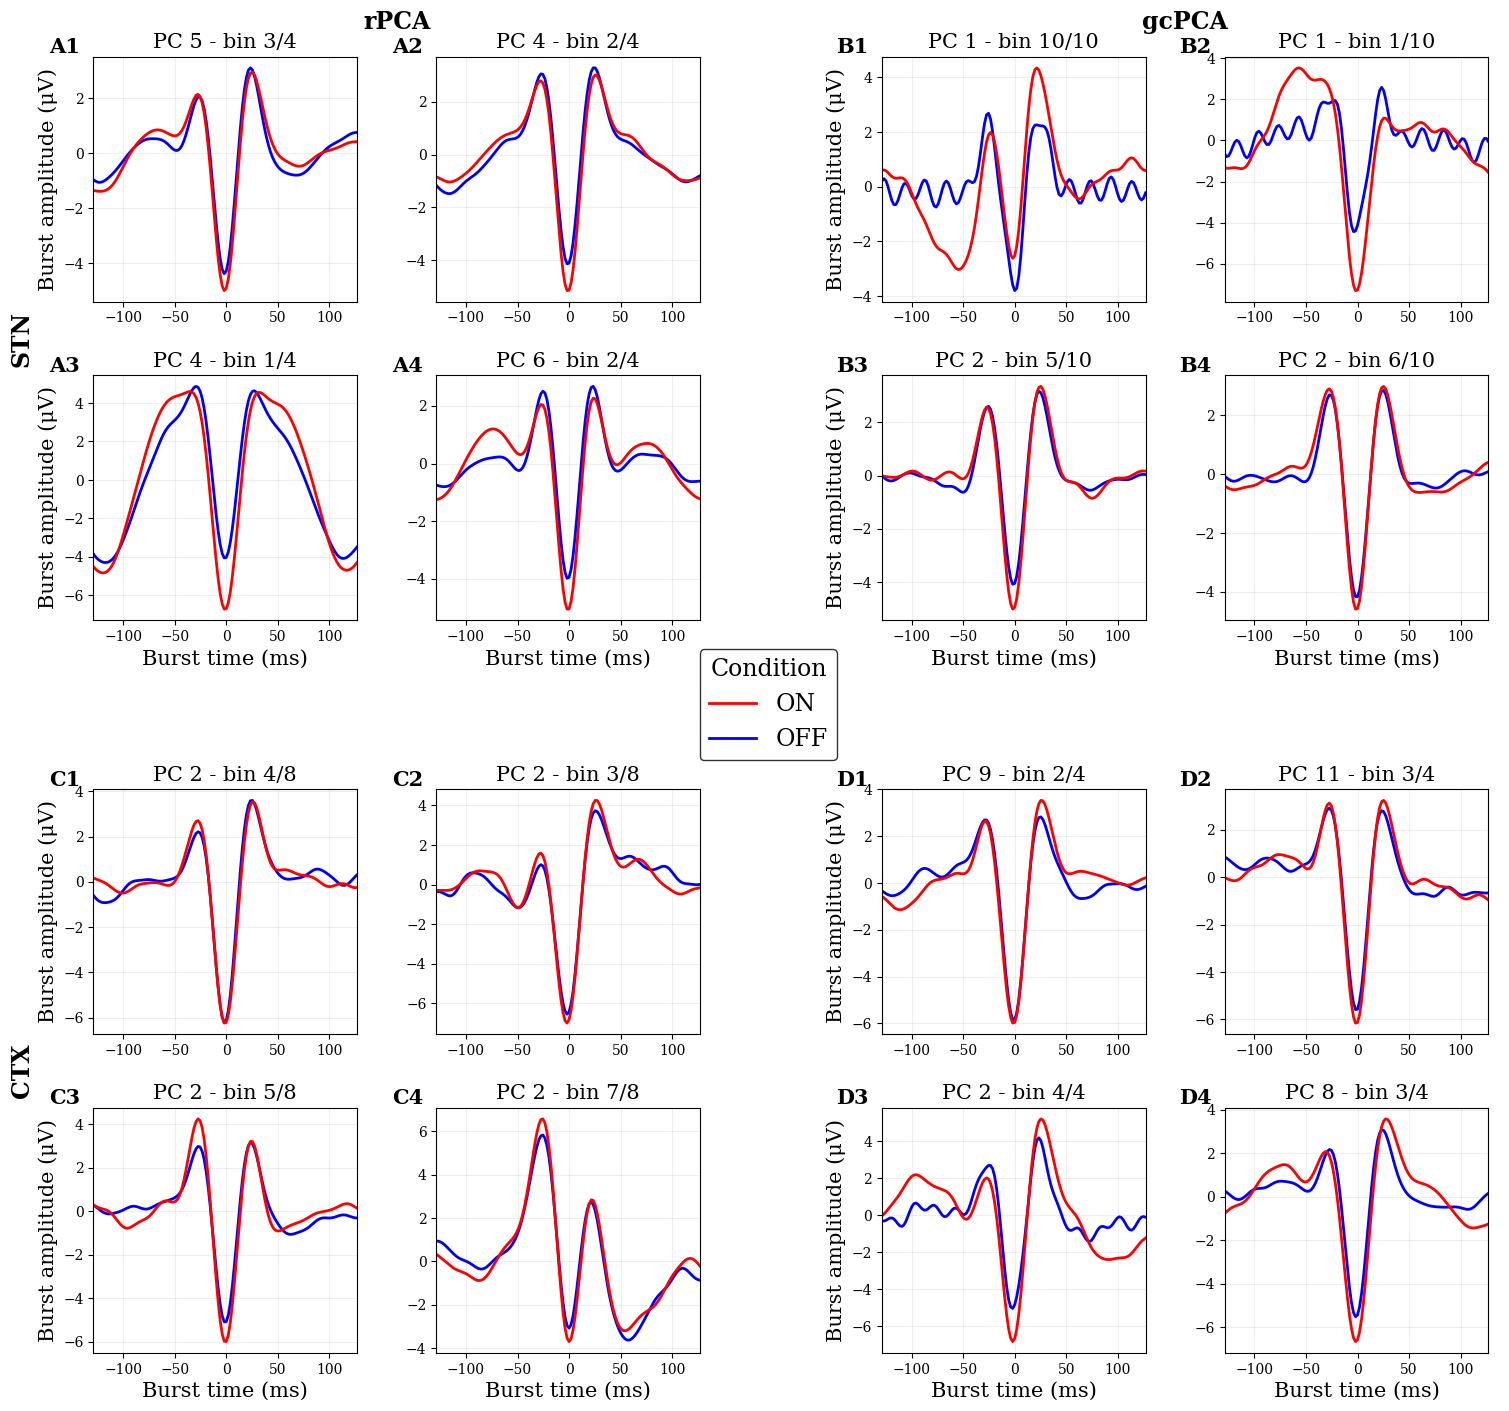

In [13]:
waveform_lookup = np.load('./outputs-7/waveforms_to_look_at.npy', allow_pickle=True).item()

methods = ['rPCA', 'gcPCA']
areas = ['stn', 'ctx']
letters = ['A', 'B', 'C', 'D']
numbers = ['1', '2', '3', '4']
fig = plt.figure(figsize=(18, 16))
outer_gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

for row, area in enumerate(areas):
    for col, method_name in enumerate(methods):

        """ --- Set ghost axes for outer quadrant titles and labels --- """
        # Create an invisible axis spanning this entier outer quadrant
        ghost_ax = fig.add_subplot(outer_gs[row, col], frame_on=False)
        ghost_ax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)

        # Set the group and y titles
        ghost_ax.set_title(f"{method_name}", fontsize=17, fontweight='bold', pad=20) if row == 0 else None
        ghost_ax.set_ylabel(f"{area.upper()}", fontsize=17, fontweight='bold', labelpad=20) if col == 0 else None

        """ --- Grab the data and set its inner subplots --- """
        lookup_key = f'{method_name}_{area}'
        config = waveform_lookup[lookup_key]

        file_name = config['file']
        n_bins = int(config['best_n_bins'])
        n_PCs = int(config['n_PCs'])

        # Create the 2x2 inner grid inside the current outer quadrant
        sub_gs = outer_gs[row, col].subgridspec(2, 2, hspace=0.30, wspace=0.30)

        # Match the letters with the current outer quadrant
        outer_gs_idx = row * 2 + col
        letter = letters[outer_gs_idx]

        for sub_gs_idx, selection in enumerate(config['top4']):
            # Compute inner row and column indices for this subplot
            inner_row = sub_gs_idx // 2
            inner_col = sub_gs_idx % 2

            # Create the actual data axis at the correct position within the inner grid
            ax = fig.add_subplot(sub_gs[inner_row, inner_col])

            on_mean, off_mean = get_saved_waveform_means(
                file_name,
                n_bins,
                selection['bin_number'],
                selection['pc_number'],
                area=area,
            )

            ax.plot(burst_times, off_mean, color='blue', linewidth=2, label='OFF')
            ax.plot(burst_times, on_mean, color='red', linewidth=2, label='ON')

            # Set the title for this subplot
            ax.set_title(f"PC {selection['pc_number']} - bin {selection['bin_number']}/{n_bins}", fontsize=15)
            ax.grid(alpha=0.2)
            ax.set_xlim(burst_times[0], burst_times[-1])

            ax.set_ylabel('Burst amplitude (μV)', fontsize=15) if inner_col == 0 else None
            ax.set_xlabel('Burst time (ms)', fontsize=15) if inner_row == 1 else None

            # Give identifying letter-number code to each subplot
            code = f"{letter}{numbers[sub_gs_idx]}"
            ax.text(
                -0.05, 1.08, code, transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top', ha='right'
            )

""" --- Set figure-level title and legend --- """
legend_lines = [plt.Line2D([0], [0], color='red', linewidth=2, label='ON'),
                plt.Line2D([0], [0], color='blue', linewidth=2, label='OFF')]

fig.legend(handles=legend_lines,
           loc='center',
           title='Condition',
           bbox_to_anchor=(0.5, 0.515),
           fontsize=17,
           title_fontsize=17, 
           framealpha=0.8, 
           edgecolor='k'
           )

# fig.suptitle('Relevant subject-average burst waveforms for logit from best models', fontsize=16)

plt.subplots_adjust(right=0.90, top=0.92)
# plt.savefig('plots/group_comparison_PCA-transformed_waveforms.png', dpi=300)
# plt.savefig('plots/group_comparison_PCA-transformed_waveforms.svg', format='svg')
plt.show()